# Per-Vehicle-Type Gaussian Models

Builds a **separate conditional multivariate-Gaussian model for each vehicle type** (sedan, suv, truck, van) from `cars_database/cleans_data/`.

`bus` and `heavy_vehicles` are skipped because their cleaned files contain no data rows.

Each model predicts the interior/geometry parameters `a_part` from a small set of easily measured exterior dimensions `b_part`, using the conditional Gaussian formula `E[a | b] = mu_a + cov_ab @ cov_bb^-1 @ (b - mu_b)`. Models are saved per type as `.npz` files.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

## 1. Configuration & data loading

In [2]:
# Vehicle types to model. bus & heavy_vehicles are skipped (their cleaned files are empty).
vehicle_types = ['sedan', 'suv', 'truck', 'van']

data_dir = Path('cars_database/cleans_data')
out_dir  = Path('gaussian_models_per_vehicle')
out_dir.mkdir(exist_ok=True)

# Columns coerced to numeric. Note: raw headers F/G are renamed to FH/RH to match gaussian.ipynb.
num_fields = ['MYR', 'OL', 'OW', 'OH', 'WB', 'CW', 'A', 'B', 'C', 'D', 'E',
              'FH', 'RH', 'TWF', 'TWR', 'YEAR']

# Parameters available for modeling / correlation (after TW is derived).
parameters = ['OL', 'OW', 'OH', 'WB', 'A', 'C', 'D', 'E', 'FH', 'RH', 'TW']

def load_clean(csv_path):
    """Load one cleaned vehicle-type CSV into a tidy, numeric DataFrame."""
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]      # drop trailing spaces ('OH ', 'CW ', 'TWR ')
    df = df.rename(columns={'F': 'FH', 'G': 'RH'})     # match naming used in gaussian.ipynb
    for field in num_fields:
        df[field] = pd.to_numeric(df[field], errors='coerce')
    df['TW'] = np.round((df['TWF'] + df['TWR']) / 2, 1)  # average track width
    return df

In [3]:
# Load every vehicle type into a dict keyed by name.
dfs = {}
for v in vehicle_types:
    dfs[v] = load_clean(data_dir / f'{v}.csv')
    complete = dfs[v][parameters].notna().all(axis=1).sum()
    print(f'{v:6} -> {len(dfs[v]):5} rows, {complete:5} rows with all parameters present')

sedan  ->  5197 rows,  4354 rows with all parameters present
suv    ->  3420 rows,  3348 rows with all parameters present
truck  ->  2264 rows,  2006 rows with all parameters present
van    ->   827 rows,   824 rows with all parameters present


## 2. Model functions

Identical conditional-Gaussian estimation to `gaussian.ipynb`, kept generic so it can be applied to each vehicle type's DataFrame.

In [4]:
def estimate_ab(a_part, b_part, df):
    """Estimate the joint Gaussian of [a_part, b_part] and return the pieces needed
    to predict a_part from b_part. Uses only rows where all of a_part+b_part are present."""
    ab = a_part + b_part
    sdf = df[df[ab].notna().all(axis=1)][ab]
    mu_a = np.mean(sdf[a_part].values, 0)
    mu_b = np.mean(sdf[b_part].values, 0)
    cov_all = np.cov(sdf.values.T)
    cov_bb = cov_all[len(a_part):, len(a_part):]
    cov_bb_inv = np.linalg.inv(cov_bb)
    cov_ab = cov_all[:len(a_part), len(a_part):]
    return mu_a, cov_ab, cov_bb_inv, mu_b


def predict_a_from_b(b_vector, mu_a, cov_ab, cov_bb_inv, mu_b):
    """Predict a_part for a single observed b_vector."""
    diff = np.asarray(b_vector) - mu_b
    predicted = mu_a + cov_ab @ cov_bb_inv @ diff
    return predicted

In [5]:
def save_gaussian_model(filename, mu_a, cov_ab, cov_bb_inv, mu_b, a_part, b_part):
    np.savez(filename, mu_a=mu_a, cov_ab=cov_ab, cov_bb_inv=cov_bb_inv, mu_b=mu_b,
             a_part=np.array(a_part, dtype=object), b_part=np.array(b_part, dtype=object))


def load_gaussian_model(filename):
    data = np.load(filename, allow_pickle=True)
    return (data['mu_a'], data['cov_ab'], data['cov_bb_inv'], data['mu_b'],
            data['a_part'].tolist(), data['b_part'].tolist())

## 3. Train & save one Gaussian model per vehicle type

Two scenarios are trained per type, differing in which exterior dimensions are treated as known inputs (`b_part`). Outputs are saved as `gaussian_models_per_vehicle/gaussian_model_<type>_<b_part>.npz`.

In [6]:
scenarios = [
    [['A', 'C', 'D', 'E', 'FH', 'RH', 'TW'], ['OW', 'WB']],
    [['A', 'C', 'D', 'E', 'FH', 'RH', 'TW'], ['OW', 'WB', 'OH', 'OL']],
]

In [7]:
# Train every (vehicle_type, scenario) pair and save a separate model file for each.
models = {}  # models[vehicle_type][b_part_name] = (mu_a, cov_ab, cov_bb_inv, mu_b)

for v in vehicle_types:
    df = dfs[v]
    models[v] = {}
    print(f'=== {v} ===')
    for a_part, b_part in scenarios:
        b_name = '_'.join(b_part)
        mu_a, cov_ab, cov_bb_inv, mu_b = estimate_ab(a_part, b_part, df)
        models[v][b_name] = (mu_a, cov_ab, cov_bb_inv, mu_b)
        fname = out_dir / f'gaussian_model_{v}_{b_name}.npz'
        save_gaussian_model(str(fname), mu_a, cov_ab, cov_bb_inv, mu_b, a_part, b_part)
        print(f'  saved {fname.name}  (predict {len(a_part)} params from {b_part})')
    print()

=== sedan ===
  saved gaussian_model_sedan_OW_WB.npz  (predict 7 params from ['OW', 'WB'])
  saved gaussian_model_sedan_OW_WB_OH_OL.npz  (predict 7 params from ['OW', 'WB', 'OH', 'OL'])

=== suv ===
  saved gaussian_model_suv_OW_WB.npz  (predict 7 params from ['OW', 'WB'])
  saved gaussian_model_suv_OW_WB_OH_OL.npz  (predict 7 params from ['OW', 'WB', 'OH', 'OL'])

=== truck ===
  saved gaussian_model_truck_OW_WB.npz  (predict 7 params from ['OW', 'WB'])
  saved gaussian_model_truck_OW_WB_OH_OL.npz  (predict 7 params from ['OW', 'WB', 'OH', 'OL'])

=== van ===
  saved gaussian_model_van_OW_WB.npz  (predict 7 params from ['OW', 'WB'])
  saved gaussian_model_van_OW_WB_OH_OL.npz  (predict 7 params from ['OW', 'WB', 'OH', 'OL'])



## 4. Per-type evaluation (80/20 train-test)

Trains on 80% of each type and reports the mean absolute prediction error per parameter on the held-out 20%, so model quality can be compared across vehicle types.

In [8]:
from sklearn.model_selection import train_test_split

for v in vehicle_types:
    print(f'================ {v} ================')
    train_df, test_df = train_test_split(dfs[v], test_size=0.2, random_state=42)
    for a_part, b_part in scenarios:
        print(f'-- inputs {b_part} --')
        mu_a, cov_ab, cov_bb_inv, mu_b = estimate_ab(a_part, b_part, train_df)
        ab = a_part + b_part
        valid_test = test_df[test_df[ab].notna().all(axis=1)]
        pred = mu_a + ((valid_test[b_part].values - mu_b) @ cov_bb_inv.T @ cov_ab.T)
        for i in range(len(a_part)):
            err = np.mean(np.abs(pred[:, i] - valid_test[a_part].values[:, i]))
            print(f'   {a_part[i]:4} MAE: {err:7.3f}  (n={len(valid_test)})')
    print()

================ sedan ================
-- inputs ['OW', 'WB'] --
   A    MAE:  10.907  (n=875)
   C    MAE:   3.485  (n=875)
   D    MAE:   3.100  (n=875)
   E    MAE:   6.792  (n=875)
   FH   MAE:   5.338  (n=875)
   RH   MAE:   8.870  (n=875)
   TW   MAE:   1.474  (n=875)
-- inputs ['OW', 'WB', 'OH', 'OL'] --
   A    MAE:   8.690  (n=875)
   C    MAE:   2.325  (n=875)
   D    MAE:   2.534  (n=875)
   E    MAE:   4.937  (n=875)
   FH   MAE:   3.612  (n=875)
   RH   MAE:   3.662  (n=875)
   TW   MAE:   1.465  (n=875)

================ suv ================
-- inputs ['OW', 'WB'] --
   A    MAE:   8.995  (n=673)
   C    MAE:   2.768  (n=673)
   D    MAE:   3.681  (n=673)
   E    MAE:   6.683  (n=673)
   FH   MAE:   5.512  (n=673)
   RH   MAE:   7.177  (n=673)
   TW   MAE:   1.673  (n=673)
-- inputs ['OW', 'WB', 'OH', 'OL'] --
   A    MAE:   8.918  (n=673)
   C    MAE:   2.216  (n=673)
   D    MAE:   3.630  (n=673)
   E    MAE:   6.677  (n=673)
   FH   MAE:   3.466  (n=673)
   RH   MAE: 

## 5. (Optional) Correlation heatmap per vehicle type

Quick visual of how parameter correlations differ between vehicle types.

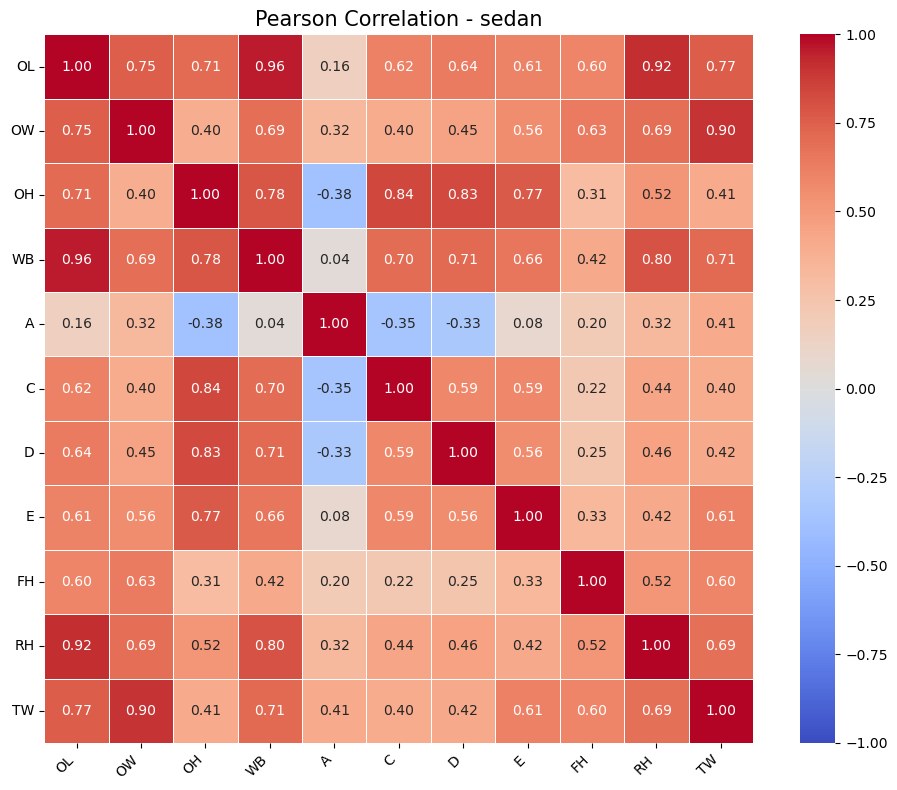

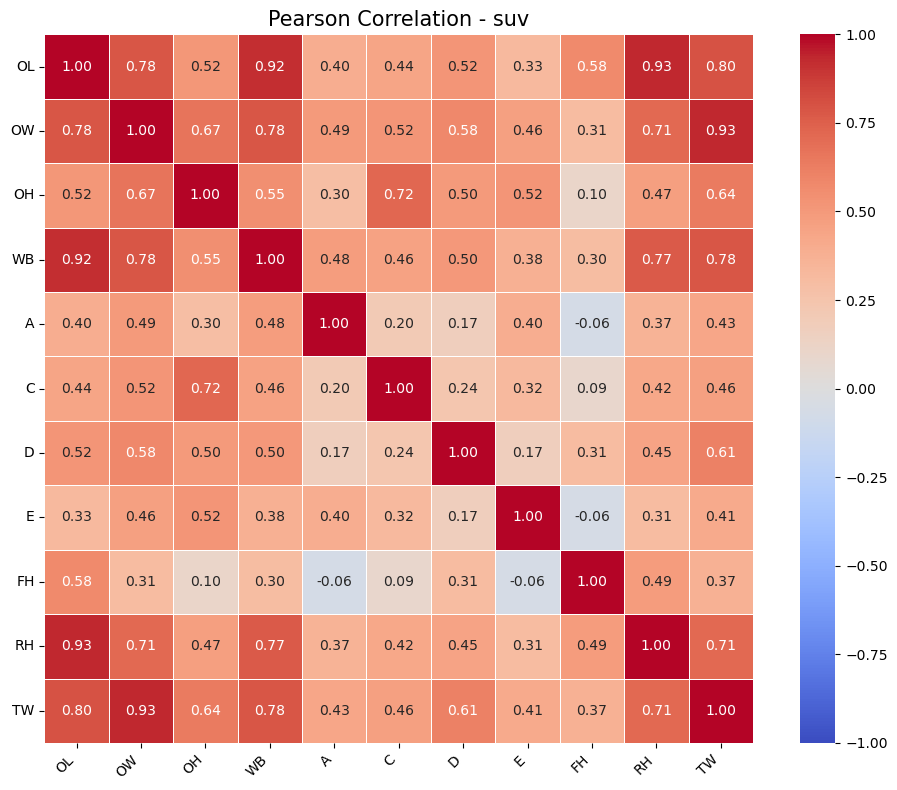

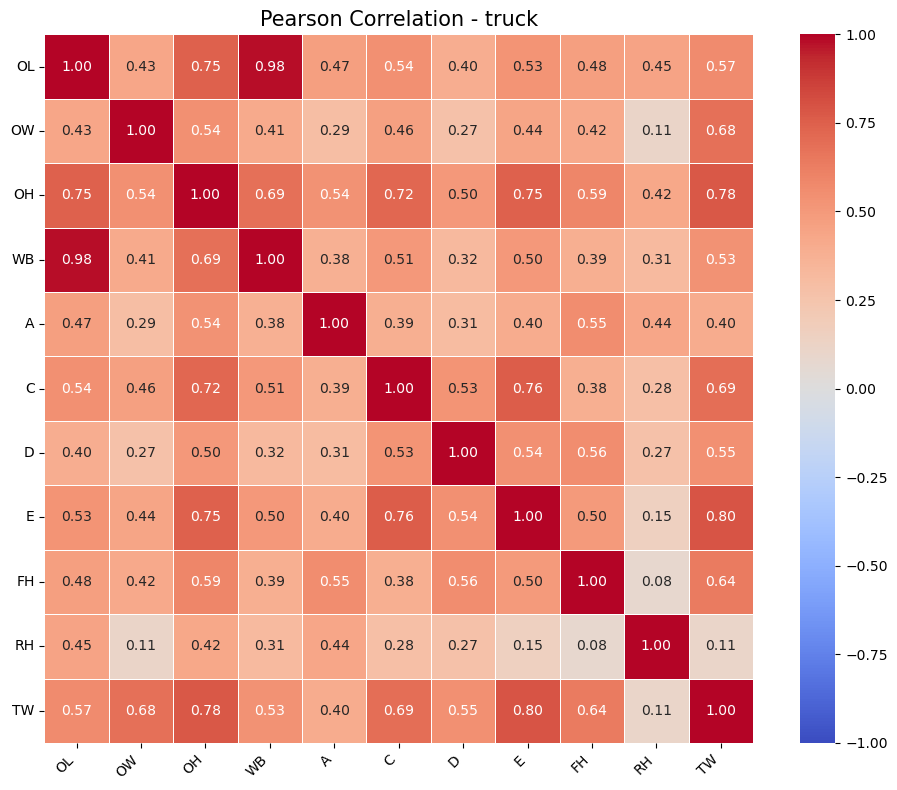

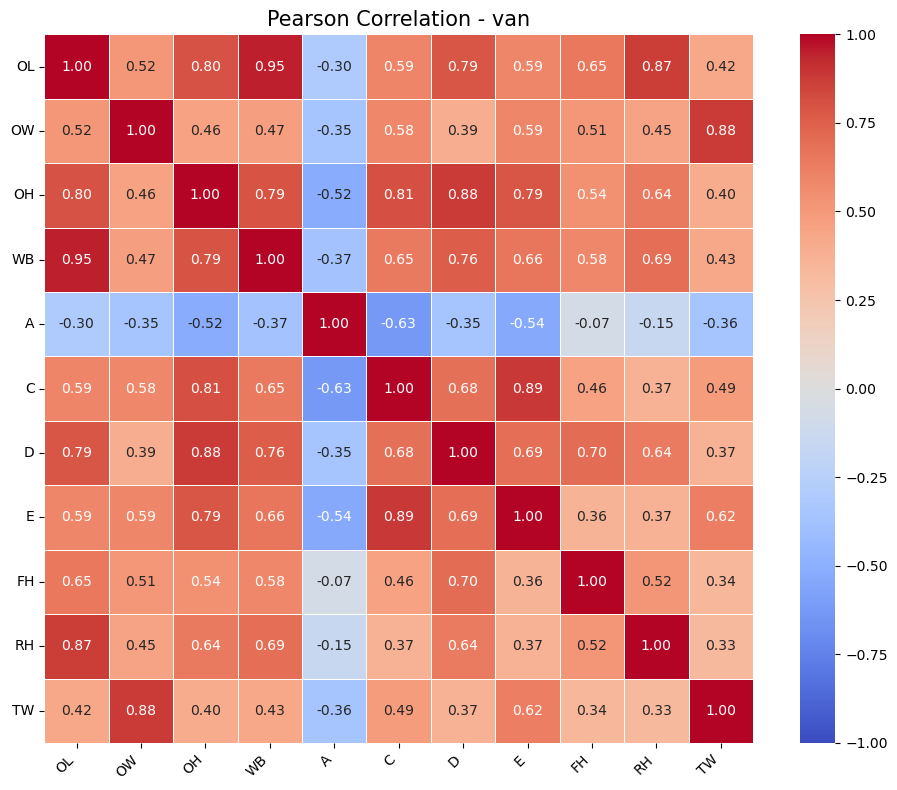

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

for v in vehicle_types:
    corr = dfs[v][parameters].corr(method='pearson')
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
                linewidths=0.5, square=True)
    plt.title(f'Pearson Correlation - {v}', fontsize=15)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(out_dir / f'correlation_heatmap_{v}.png', dpi=200)
    plt.show()